### ==============================================================================
## Combined Salinity Profiles - All Campaigns
### Authors: Elisabet Verger-Miralles (everger@imedea.uib-csic.es)
### Data from FaSt-SWOT (Leg 1 & 2) and BioSWOT experiments
# 
**DESCRIPTION**:
This script generates a comprehensive figure displaying all salinity profiles
from all campaigns. Each subplot shows MVP Raw, MVP Processed (Step 5), and 
CTD Reference for comparison. Total: 14 subplots (Leg1: 5, Leg2: 4, BioSWOT: 5).
#
INPUT: Raw MVP files (Step 1), Final MVP files (Step 5), and Reference CTD (.cnv).
#
OUTPUT: Combined salinity profiles figure (.png).
### ==============================================================================


In [11]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
from pathlib import Path
from geopy.distance import geodesic
import gsw
import re
import io
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# CONFIGURATION
# ==========================================
BASE_ROOT_FASTSWOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_fastswot_nc_final_processing")
BASE_ROOT_BIOSWOT = Path(r"C:\Users\ASUS\Desktop\MVP\MVP_paper_data_figures_publish\MVP_bioswot_nc_final_processing")


def resolve_final_dir(preferred_step7: Path, fallback_step6: Path) -> Path:
    """Use Step 7 directory when available, fallback to Step 6 for compatibility."""
    return preferred_step7 if preferred_step7.exists() else fallback_step6


# FaSt-SWOT Leg 1
DIR_MVP_RAW_LEG1 = BASE_ROOT_FASTSWOT / "Data" / "Leg1" / "processed_step1_highres_qc"
DIR_MVP_FINAL_LEG1 = resolve_final_dir(
    BASE_ROOT_FASTSWOT / "Data" / "Leg1" / "processed_step7_with_offset",
    BASE_ROOT_FASTSWOT / "Data" / "Leg1" / "processed_step6_with_offset",
)
DIR_CTD_LEG1 = Path(r"C:/Users/ASUS/OneDrive - Universitat de les Illes Balears/SWOT/CTD/CTD_data/leg1/HM/")

# FaSt-SWOT Leg 2
DIR_MVP_RAW_LEG2 = BASE_ROOT_FASTSWOT / "Data" / "Leg2" / "processed_step1_highres_qc"
DIR_MVP_FINAL_LEG2 = resolve_final_dir(
    BASE_ROOT_FASTSWOT / "Data" / "Leg2" / "processed_step7_with_offset",
    BASE_ROOT_FASTSWOT / "Data" / "Leg2" / "processed_step6_with_offset",
)
DIR_CTD_LEG2 = Path(r"C:/Users/ASUS/OneDrive - Universitat de les Illes Balears/SWOT/CTD/CTD_data/leg2/HM/")

# BioSWOT
DIR_MVP_RAW_BIOSWOT = BASE_ROOT_BIOSWOT / "Data" / "processed_step1_highres_qc"
DIR_MVP_FINAL_BIOSWOT = resolve_final_dir(
    BASE_ROOT_BIOSWOT / "Data" / "processed_step7_with_offset",
    BASE_ROOT_BIOSWOT / "Data" / "processed_step6_with_offset",
)
DIR_CTD_BIOSWOT = Path(r"C:\Users\ASUS\Desktop\BioSWOT_data\CTD\cnv")

# Output
OUTDIR = BASE_ROOT_FASTSWOT / "Figures" / "FIGURES_PAPER_COMBINED"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Parameters
MAX_DIST_KM = 0.5
MAX_TIME_MIN = 60.0
CTD_SMOOTH_WINDOW = 8
Z_MAX_PLOT = 250.0  # Will adapt based on campaign

print("Configuration loaded. Standards: MVP Raw (gray), MVP Processed (red), CTD Reference (black)")
print(f"Final product directories: L1={DIR_MVP_FINAL_LEG1.name}, L2={DIR_MVP_FINAL_LEG2.name}, BioSWOT={DIR_MVP_FINAL_BIOSWOT.name}")

Configuration loaded. Standards: MVP Raw (gray), MVP Processed (red), CTD Reference (black)
Final product directories: L1=processed_step6_with_offset, L2=processed_step6_with_offset, BioSWOT=processed_step6_with_offset


In [12]:
# ==========================================
# SUPPORT FUNCTIONS
# ==========================================

def read_ctd_robust(path):
    """Read CTD .cnv file and extract pressure, temperature, salinity, conductivity."""
    try:
        with open(path, 'r', encoding='latin-1') as f:
            lines = f.readlines()
        lat, lon, time_val, start_idx = np.nan, np.nan, pd.NaT, 0
        col_map = {}

        for i, line in enumerate(lines):
            if 'NMEA Latitude' in line:
                p = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if len(p) >= 2:
                    lat = float(p[0]) + float(p[1]) / 60 * (-1 if 'S' in line else 1)
            if 'NMEA Longitude' in line:
                p = re.findall(r"[-+]?\d*\.\d+|\d+", line)
                if len(p) >= 2:
                    lon = float(p[0]) + float(p[1]) / 60 * (-1 if 'W' in line else 1)
            if 'start_time' in line:
                try:
                    time_val = pd.to_datetime(line.split('=')[1].strip().split('[')[0])
                except:
                    pass
            if '# name' in line:
                match = re.search(r"name (\d+)", line)
                if match:
                    idx = int(match.group(1))
                    name = line.split('=')[1].split(':')[0].strip().lower()
                    if name in ['prdm', 'pres', 'pressure']:
                        col_map['p'] = idx
                    elif name in ['t090c', 't190c', 'temp', 'tv290c']:
                        col_map['t'] = idx
                    elif name in ['sal00', 'sal11', 'sal', 'psal']:
                        col_map['s'] = idx
                    elif name in ['c0s/m', 'c1s/m', 'cond', 'c0ms/cm']:
                        col_map['c'] = idx
            if '*END*' in line:
                start_idx = i + 1
                break

        df = pd.read_csv(io.StringIO("".join(lines[start_idx:])), delim_whitespace=True, header=None)
        p = df.iloc[:, col_map['p']].values
        t = df.iloc[:, col_map['t']].values
        s = df.iloc[:, col_map['s']].values
        c = df.iloc[:, col_map['c']].values if 'c' in col_map else None
        if c is not None and np.nanmean(c) < 10:
            c *= 10.0

        return {'lat': lat, 'lon': lon, 'time': time_val, 'id': path.stem, 'p': p, 't': t, 's': s, 'c': c}
    except:
        return None


def load_mvp_catalog(mvp_dir):
    """Load all MVP files from directory and extract metadata."""
    data = []
    files = sorted(list(mvp_dir.glob("*.nc")))
    for f in files:
        try:
            with xr.open_dataset(f) as ds:
                lat = ds.latitude.values.flatten()[0] if 'latitude' in ds else np.nan
                lon = ds.longitude.values.flatten()[0] if 'longitude' in ds else np.nan
                t_val = pd.to_datetime(ds.time.values.flatten()[0]) if 'time' in ds else pd.NaT
                if np.isfinite(lat):
                    data.append({'file': f.name, 'lat': lat, 'lon': lon, 'time': t_val, 'path': f})
        except:
            pass
    return pd.DataFrame(data)


def find_best_ctd_match(mvp_catalog, ctd_list, max_dist_km, max_time_min):
    """Find best MVP-CTD matches for a campaign."""
    matches = []

    for ctd in ctd_list:
        if not ctd or pd.isna(ctd['time']):
            continue

        mvp_catalog['dist_km'] = [geodesic((ctd['lat'], ctd['lon']), (m.lat, m.lon)).km
                                   for m in mvp_catalog.itertuples()]
        mvp_catalog['dt_min'] = [(abs(m.time - ctd['time']).total_seconds() / 60.0)
                                 for m in mvp_catalog.itertuples()]

        valid = mvp_catalog[(mvp_catalog['dist_km'] <= max_dist_km) & (mvp_catalog['dt_min'] <= max_time_min)]

        if not valid.empty:
            best_idx = valid['dist_km'].idxmin()
            matches.append({
                'ctd': ctd,
                'mvp': valid.loc[best_idx],
                'dist_km': valid.loc[best_idx, 'dist_km'],
                'dt_min': valid.loc[best_idx, 'dt_min']
            })

    return matches


def build_final_candidates(raw_mvp_filename: str):
    """Generate candidate filenames for final MVP product across old/new conventions."""
    candidates = []

    if raw_mvp_filename.endswith(".nc"):
        stem = raw_mvp_filename[:-3]
    else:
        stem = raw_mvp_filename

    replacement_map = [
        ("_step1_qc", "_step7_with_offset"),
        ("_step1_qc", "_step6_with_offset"),
        ("_step1", "_step7_with_offset"),
        ("_step1", "_step6_with_offset"),
        ("_step5", "_step7_with_offset"),
        ("_step5", "_step6_with_offset"),
    ]

    for old, new in replacement_map:
        if old in stem:
            candidates.append(stem.replace(old, new) + ".nc")

    # Fallbacks in case naming does not include a step suffix
    candidates.extend([
        stem + "_step7_with_offset.nc",
        stem + "_step6_with_offset.nc",
        raw_mvp_filename,
    ])

    # Keep unique values preserving order
    seen = set()
    unique_candidates = []
    for name in candidates:
        if name not in seen:
            seen.add(name)
            unique_candidates.append(name)

    return unique_candidates


def pick_existing_file(base_dir: Path, filename_candidates):
    """Return first existing file from a candidate list."""
    for name in filename_candidates:
        p = base_dir / name
        if p.exists():
            return p
    return None


def read_first_existing_var(ds: xr.Dataset, candidates):
    """Read first variable found in dataset from a list of candidate names."""
    for name in candidates:
        if name in ds.variables:
            return ds[name].values, name
    raise KeyError(f"None of these variables found: {candidates}")


print("Support functions loaded.")

Support functions loaded.


In [13]:
# ==========================================
# LOAD ALL DATA FROM THE THREE CAMPAIGNS
# ==========================================

all_profiles = []

# ------- LEG 1 -------
print("\n== Loading FaSt-SWOT LEG 1 ===")
df_mvp_leg1 = load_mvp_catalog(DIR_MVP_RAW_LEG1)
ctd_list_leg1 = [read_ctd_robust(f) for f in sorted(DIR_CTD_LEG1.glob("d*.cnv"))]
matches_leg1 = find_best_ctd_match(df_mvp_leg1.copy(), ctd_list_leg1, MAX_DIST_KM, MAX_TIME_MIN)
print(f"Found {len(matches_leg1)} profiles for Leg 1")

# ------- LEG 2 -------
print("\n== Loading FaSt-SWOT LEG 2 ===")
df_mvp_leg2 = load_mvp_catalog(DIR_MVP_RAW_LEG2)
ctd_list_leg2 = [read_ctd_robust(f) for f in sorted(DIR_CTD_LEG2.glob("d*.cnv"))]
matches_leg2 = find_best_ctd_match(df_mvp_leg2.copy(), ctd_list_leg2, MAX_DIST_KM, MAX_TIME_MIN)
print(f"Found {len(matches_leg2)} profiles for Leg 2")

# ------- BIOSWOT -------
print("\n== Loading BioSWOT ===")
df_mvp_bioswot = load_mvp_catalog(DIR_MVP_RAW_BIOSWOT)
ctd_list_bioswot = [read_ctd_robust(f) for f in sorted(DIR_CTD_BIOSWOT.glob("*.cnv"))]
matches_bioswot = find_best_ctd_match(df_mvp_bioswot.copy(), ctd_list_bioswot, 2.5, 120.0)
print(f"Found {len(matches_bioswot)} profiles for BioSWOT")

# Combine all matches
all_matches = matches_leg1 + matches_leg2 + matches_bioswot
print(f"\n✅ TOTAL profiles loaded: {len(all_matches)}")


== Loading FaSt-SWOT LEG 1 ===
Found 5 profiles for Leg 1

== Loading FaSt-SWOT LEG 2 ===
Found 4 profiles for Leg 2

== Loading BioSWOT ===
Found 5 profiles for BioSWOT

✅ TOTAL profiles loaded: 14


In [14]:
# ==========================================
# PROCESS AND EXTRACT SALINITY DATA
# ==========================================

profiles_data = []

for idx, match in enumerate(all_matches):
    ctd = match['ctd']
    mvp_file = match['mvp']['file']

    # Determine campaign and directories
    if 'Leg1' in str(match['mvp']['path']):
        dir_raw = DIR_MVP_RAW_LEG1
        dir_final = DIR_MVP_FINAL_LEG1
        campaign = "Leg 1"
        z_max = 100.0
    elif 'Leg2' in str(match['mvp']['path']):
        dir_raw = DIR_MVP_RAW_LEG2
        dir_final = DIR_MVP_FINAL_LEG2
        campaign = "Leg 2"
        z_max = 200.0
    else:  # BioSWOT
        dir_raw = DIR_MVP_RAW_BIOSWOT
        dir_final = DIR_MVP_FINAL_BIOSWOT
        campaign = "BioSWOT"
        z_max = 350.0

    raw_path = dir_raw / mvp_file

    # Resolve final file robustly: Step 7 preferred, Step 6 compatible fallback
    final_candidates = build_final_candidates(mvp_file)
    final_path = pick_existing_file(dir_final, final_candidates)

    if final_path is None:
        print(f"⚠️ {ctd['id']}: Final file not found in {dir_final.name}")
        continue

    try:
        with xr.open_dataset(final_path) as ds_f, xr.open_dataset(raw_path) as ds_r:
            # MVP Processed (new and legacy variable naming supported)
            p_p, p_name = read_first_existing_var(ds_f, ['pressure', 'pres', 'p'])
            s_p, s_name = read_first_existing_var(
                ds_f,
                [
                    'practical_salinity_processed',
                    'salinity_practical_processed',
                    'salinity_practical',
                    'salinity_processed',
                    'salinity',
                ],
            )

            # MVP Raw
            p_r = ds_r.pressure.values
            t_r = ds_r.t1.values
            c_r = ds_r.c1.values
            if np.nanmean(c_r) < 10:
                c_r *= 10
            s_r = gsw.SP_from_C(c_r, t_r, p_r)

        # CTD Reference (smoothed)
        s_ctd_smooth = pd.Series(ctd['s']).rolling(window=CTD_SMOOTH_WINDOW, center=True, min_periods=1).mean().values

        # Calculate RMSD reduction between MVP Raw and MVP Processed relative to CTD
        # Interpolate all to CTD pressure levels for comparison
        from scipy.interpolate import interp1d

        def calculate_rmsd(s1, p1, s_ref, p_ref):
            """Calculate RMSD after interpolating to reference pressure levels"""
            valid_ref = np.isfinite(s_ref)
            p_ref_valid = p_ref[valid_ref]
            s_ref_valid = s_ref[valid_ref]

            if len(s_ref_valid) < 2:
                return np.nan

            try:
                valid_data = np.isfinite(s1) & np.isfinite(p1)
                if np.sum(valid_data) < 2:
                    return np.nan

                f = interp1d(p1[valid_data], s1[valid_data], bounds_error=False, fill_value=np.nan)
                s1_interp = f(p_ref_valid)

                valid_interp = np.isfinite(s1_interp)
                if np.sum(valid_interp) < 2:
                    return np.nan

                rmsd = np.sqrt(np.mean((s1_interp[valid_interp] - s_ref_valid[valid_interp]) ** 2))
                return rmsd
            except:
                return np.nan

        def calculate_bias(s1, p1, s_ref, p_ref):
            """Calculate BIAS (mean signed error) after interpolating to reference pressure levels"""
            valid_ref = np.isfinite(s_ref)
            p_ref_valid = p_ref[valid_ref]
            s_ref_valid = s_ref[valid_ref]

            if len(s_ref_valid) < 2:
                return np.nan

            try:
                valid_data = np.isfinite(s1) & np.isfinite(p1)
                if np.sum(valid_data) < 2:
                    return np.nan

                f = interp1d(p1[valid_data], s1[valid_data], bounds_error=False, fill_value=np.nan)
                s1_interp = f(p_ref_valid)

                valid_interp = np.isfinite(s1_interp)
                if np.sum(valid_interp) < 2:
                    return np.nan

                bias = np.mean(s1_interp[valid_interp] - s_ref_valid[valid_interp])
                return bias
            except:
                return np.nan

        rmsd_raw = calculate_rmsd(s_r, p_r, s_ctd_smooth, ctd['p'])
        rmsd_proc = calculate_rmsd(s_p, p_p, s_ctd_smooth, ctd['p'])
        bias_raw = calculate_bias(s_r, p_r, s_ctd_smooth, ctd['p'])
        bias_proc = calculate_bias(s_p, p_p, s_ctd_smooth, ctd['p'])

        if not np.isnan(rmsd_raw) and rmsd_raw > 0:
            rmsd_reduction = ((rmsd_raw - rmsd_proc) / rmsd_raw) * 100.0
        else:
            rmsd_reduction = np.nan

        # Bias reduction: how much the bias magnitude decreased
        if not np.isnan(bias_raw) and bias_raw != 0:
            bias_reduction = ((abs(bias_raw) - abs(bias_proc)) / abs(bias_raw)) * 100.0
        else:
            bias_reduction = np.nan

        profiles_data.append({
            'ctd_id': ctd['id'],
            'campaign': campaign,
            'p_raw': p_r,
            's_raw': s_r,
            'p_proc': p_p,
            's_proc': s_p,
            'p_ctd': ctd['p'],
            's_ctd': s_ctd_smooth,
            'z_max': z_max,
            'dist_km': match['dist_km'],
            'dt_min': match['dt_min'],
            'rmsd_reduction': rmsd_reduction,
            'bias_raw': bias_raw,
            'bias_proc': bias_proc,
            'bias_reduction': bias_reduction,
            'final_file': final_path.name,
            'final_salinity_var': s_name,
        })
        print(
            f"✅ {ctd['id']} ({campaign}) | File={final_path.name} | Var={s_name} | "
            f"Δt={match['dt_min']:.1f}min | Δd={match['dist_km']:.2f}km | "
            f"RMSD Δ={rmsd_reduction:.1f}% | Bias Δ={bias_reduction:.1f}%"
        )

    except Exception as e:
        print(f"❌ Error processing {ctd['id']}: {e}")

print(f"\n✅ Successfully processed {len(profiles_data)} profiles")

✅ dstation_02 (Leg 1) | File=imedea-socib_fast-swot1_mvp_0153_step6_with_offset.nc | Var=practical_salinity_processed | Δt=24.2min | Δd=0.48km | RMSD Δ=51.9% | Bias Δ=63.7%
✅ dstation_04 (Leg 1) | File=imedea-socib_fast-swot1_mvp_0202_step6_with_offset.nc | Var=practical_salinity_processed | Δt=34.1min | Δd=0.39km | RMSD Δ=63.3% | Bias Δ=76.5%
✅ dstation_09 (Leg 1) | File=imedea-socib_fast-swot1_mvp_0617_step6_with_offset.nc | Var=practical_salinity_processed | Δt=38.0min | Δd=0.46km | RMSD Δ=80.9% | Bias Δ=70.3%
✅ dstation_10 (Leg 1) | File=imedea-socib_fast-swot1_mvp_0627_step6_with_offset.nc | Var=practical_salinity_processed | Δt=40.7min | Δd=0.23km | RMSD Δ=48.2% | Bias Δ=-98.9%
✅ dstation_11 (Leg 1) | File=imedea-socib_fast-swot1_mvp_0632_step6_with_offset.nc | Var=practical_salinity_processed | Δt=35.2min | Δd=0.24km | RMSD Δ=71.3% | Bias Δ=99.6%
✅ ds2-03 (Leg 2) | File=imedea-socib_fast-swot2_mvp_0097_step6_with_offset.nc | Var=practical_salinity_processed | Δt=42.5min | Δd=0.3

In [15]:
# Analyze BIAS in detail - all profiles
print("=" * 80)
print("DETAILED BIAS ANALYSIS")
print("=" * 80)

# Calculate bias values for all profiles
print("\nDetailed Bias Values per Profile:")
print(f"{'Station':<20} {'Campaign':<10} {'Bias Raw':<12} {'Bias Proc':<12} {'Reduction %':<15}")
print("-" * 80)

for p in profiles_data:
    bias_raw = p['bias_raw']
    bias_proc = p['bias_proc']
    bias_red = p['bias_reduction']
    print(f"{p['ctd_id']:<20} {p['campaign']:<10} {bias_raw:>+10.4f} {bias_proc:>+10.4f} {bias_red:>+12.1f}%")

# Summary statistics
print("\n" + "=" * 80)
print("CAMPAIGN STATISTICS")
print("=" * 80)

for campaign in ['Leg 1', 'Leg 2', 'BioSWOT']:
    campaign_data = [p for p in profiles_data if p['campaign'] == campaign]
    
    bias_raw_vals = [p['bias_raw'] for p in campaign_data if not np.isnan(p['bias_raw'])]
    bias_proc_vals = [p['bias_proc'] for p in campaign_data if not np.isnan(p['bias_proc'])]
    bias_red_vals = [p['bias_reduction'] for p in campaign_data if not np.isnan(p['bias_reduction'])]
    
    print(f"\n📊 {campaign}:")
    print(f"   Avg Raw Bias:  {np.mean(bias_raw_vals):+.4f} (subdatación < 0, sobreestimación > 0)")
    print(f"   Avg Proc Bias: {np.mean(bias_proc_vals):+.4f}")
    print(f"   Avg Bias Reduction: {np.mean(bias_red_vals):+.1f}%")
    
    # Check for sign changes
    sign_changes = sum(1 for bias_r, bias_p in zip(bias_raw_vals, bias_proc_vals) 
                       if np.sign(bias_r) != np.sign(bias_p))
    if sign_changes > 0:
        print(f"   ⚠️ {sign_changes} profiles changed bias sign (subdatación ↔ sobreestimación)")

DETAILED BIAS ANALYSIS

Detailed Bias Values per Profile:
Station              Campaign   Bias Raw     Bias Proc    Reduction %    
--------------------------------------------------------------------------------
dstation_02          Leg 1         +0.0224    +0.0081        +63.7%
dstation_04          Leg 1         +0.0174    +0.0041        +76.5%
dstation_09          Leg 1         +0.0059    -0.0017        +70.3%
dstation_10          Leg 1         -0.0073    -0.0145        -98.9%
dstation_11          Leg 1         +0.0078    -0.0000        +99.6%
ds2-03               Leg 2         +0.0246    +0.0049        +80.2%
ds4-04               Leg 2         +0.0111    -0.0086        +22.8%
ds4-06               Leg 2         +0.0032    -0.0165       -411.1%
ds5-09               Leg 2         +0.0256    +0.0059        +77.0%
bioswot2023_0017     BioSWOT       +0.0034    +0.0035         -3.7%
bioswot2023_0018     BioSWOT       -0.0287    -0.0284         +1.0%
bioswot2023_0019     BioSWOT       -0.0

In [ ]:

legend_label_mapping = {
    'dstation_04': 'FaSt-SWOT L1 st. 04',
    'dstation_09': 'FaSt-SWOT L1 st. 09',
    'dstation_11': 'FaSt-SWOT L1 st. 11',
    'ds2-03': 'FaSt-SWOT L2 st. 03',
    'ds4-06': 'FaSt-SWOT L2 st. 06',
    'ds5-09': 'FaSt-SWOT L2 st. 09',
    'bioswot2023_0017': 'BioSWOT-Med st. 17',
    'bioswot2023_0019': 'BioSWOT-Med st. 19',
    'bioswot2023_0024': 'BioSWOT-Med st. 24',
}

# Selected 9 profiles for 3x3 figure
selected_ids = list(legend_label_mapping.keys())
filtered_profiles = [p for p in profiles_data if p['ctd_id'] in selected_ids]


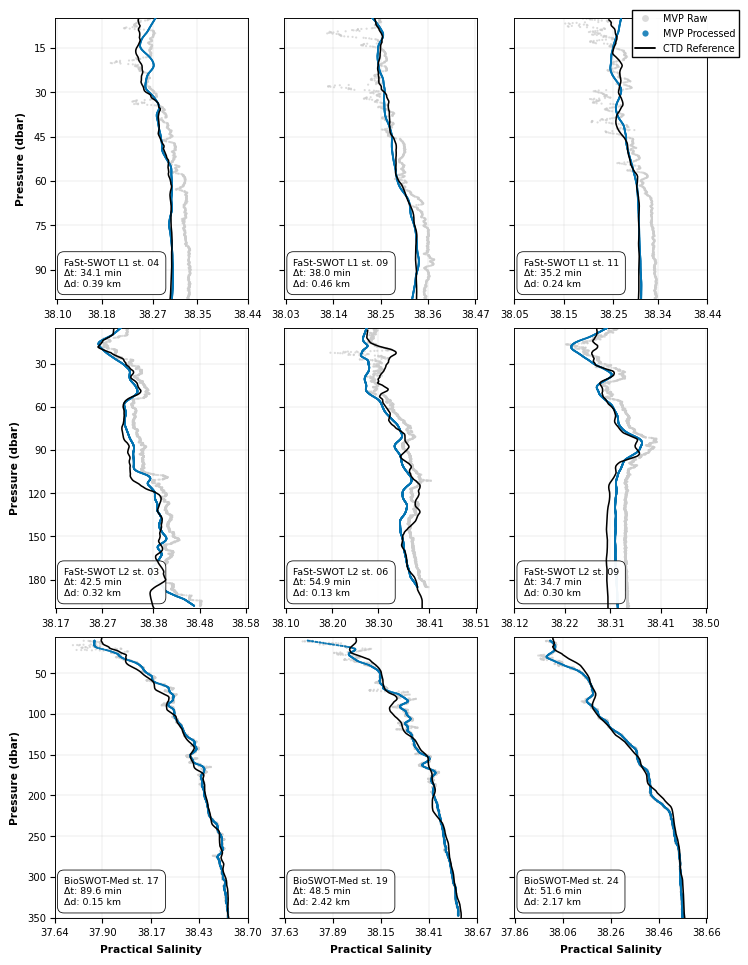

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ==========================================
# IMPROVED PAPER-LIKE SALINITY FIGURE - COLORBLIND FRIENDLY
# ==========================================

# Factor de escala exacto para Google Docs (ancho de 16 -> 7.2 pulgadas)
S = 7.2 / 16  # S será 0.45

# Multiplicamos el figsize por S para obtener ~ (7.2, 9.45) pulgadas
fig, axs = plt.subplots(3, 3, figsize=(16 * S, 21 * S), sharex=False, sharey=False, constrained_layout=True)

# Colorblind-friendly color scheme - Publication quality
color_raw = '#CCCCCC'      # Light gray for raw
color_proc = '#0173B2'     # Blue for processed
color_ctd = '#000000'      # Black for CTD reference

# Plot each selected profile
for idx, profile in enumerate(filtered_profiles):
    row = idx // 3
    col = idx % 3
    ax = axs[row, col]
    
    # Plot data - Escalamos áreas (s) al cuadrado y grosores (lw) de forma lineal
    ax.scatter(profile['s_raw'], profile['p_raw'], s=12 * (S**2), color=color_raw, alpha=0.7, 
               edgecolors='none', label='MVP Raw', zorder=2)
    ax.scatter(profile['s_proc'], profile['p_proc'], s=9 * (S**2), color=color_proc, alpha=0.85, 
               edgecolors='none', label='MVP Processed', zorder=3)
    ax.plot(profile['s_ctd'], profile['p_ctd'], color=color_ctd, lw=2.5 * S, zorder=4, 
            label='CTD Reference')
    
    # Formatting - inverted pressure axis
    ax.invert_yaxis()
    ax.set_ylim(profile['z_max'], 5)
    
    # Adaptive x-axis with consistent tick spacing
    s_valid = profile['s_raw'][np.isfinite(profile['s_raw'])]
    if len(s_valid) > 0:
        s_min = np.min(s_valid) - 0.1
        s_max = np.max(s_valid) + 0.1
        ax.set_xlim(s_min, s_max)
        
        # Fixed number of ticks
        x_range = s_max - s_min
        if x_range < 0.5:
            step = 0.1
            n_ticks = 5
        elif x_range < 1.0:
            step = 0.2
            n_ticks = 5
        else:
            step = 0.5
            n_ticks = 5
        
        # Create evenly spaced ticks
        x_ticks = np.round(np.linspace(s_min, s_max, n_ticks), 2)
        ax.set_xticks(x_ticks)
        # Escalamos la fuente de los números del eje X
        ax.set_xticklabels([f'{x:.2f}' for x in x_ticks], fontsize=15 * S, fontweight='normal')
    
    # Professional grid - subtle but visible (escalamos linewidth)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.7 * S, color='#808080')
    ax.set_axisbelow(True)
    
    # Larger labels for publication - ENHANCED (escalamos todos los parámetros)
    ax.tick_params(labelsize=16 * S, width=1.8 * S, length=8 * S, colors='black', direction='out')
    
    # Y-axis formatting
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=7))
    ax.tick_params(axis='y', which='major', pad=5 * S)
    
    # Y-label: only on left column
    if col == 0:
        ax.set_ylabel('Pressure (dbar)', fontsize=17 * S, fontweight='bold', labelpad=12 * S)
    else:
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelleft=False)
    
    # X-label: only on bottom row
    if row == 2:
        ax.set_xlabel('Practical Salinity', fontsize=17 * S, fontweight='bold', labelpad=12 * S)
    else:
        ax.set_xlabel('')
    
    # Enhanced spines - publication quality
    for spine_name, spine in ax.spines.items():
        spine.set_linewidth(1.5 * S)
        spine.set_color('black')
    
    # Station metadata in elegant box
    station_label = legend_label_mapping.get(profile['ctd_id'], profile['ctd_id'])
    dt_min = profile['dt_min']
    dist_km = profile['dist_km']
    
    # Compact but readable legend
    info_text = f"{station_label}\nΔt: {dt_min:.1f} min \nΔd: {dist_km:.2f} km"
    
    # Escalamos fuente y bordes de la caja de texto
    ax.text(0.048, 0.04, info_text, transform=ax.transAxes, fontsize=15 * S, 
            verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.7', 
            facecolor='white', alpha=0.95, edgecolor='black', linewidth=1.3 * S))

# Create high-quality shared legend (escalamos markersize, lw, markeredgewidth)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color_raw, markersize=11 * S, 
           markeredgecolor='none', label='MVP Raw', alpha=0.7, markeredgewidth=0),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color_proc, markersize=10 * S, 
           markeredgecolor='none', label='MVP Processed', alpha=0.85, markeredgewidth=0),
    Line2D([0], [0], color=color_ctd, lw=3 * S, label='CTD Reference', solid_capstyle='round'),
]

# Escalamos la fuente de la leyenda
fig.legend(handles=legend_elements, loc='upper right', fontsize=15.5 * S, framealpha=0.98,
           edgecolor='black', fancybox=False, frameon=True, bbox_to_anchor=(1.025, 1.01))

# Save with publication-quality settings for GDocs (600 DPI con tamaño físico ajustado)
output_path_improved = OUTDIR / "Salinity_Profiles_3x3.png"
plt.savefig(output_path_improved, dpi=600, bbox_inches='tight', facecolor='white', 
            edgecolor='none', pad_inches=0.05)

plt.show()